# Cross-dataset evaluation (generalization)

Load a trained checkpoint and evaluate on a **held-out dataset** (different from training) to measure generalization.

**Default config:** `dual_maxvit` teacher checkpoint on **CIFAKE** `test` split (model trained on DeepDetect-2025).

Label convention (matches training notebook): **0 = real**, **1 = fake**.

Set `EVAL_CONFIG` below, then run all cells. For local runs, place data under `datasets/cifake` or set `DF_DATA_ROOT`.

In [1]:
!pip install -q --upgrade "timm>=1.0,<2" "albumentations>=1.4,<2" opencv-python-headless scikit-learn tqdm matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 92.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.9/274.9 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 186.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 176.6 MB/s eta 0:00:00


In [2]:
import os
import re
import json
import random
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

/usr/local/lib/python3.12/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.24). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [3]:
SEED = 42


def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()


class CFG:
    num_workers = 2 if os.name == "nt" else 4
    use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()


def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for base in (cwd, cwd.parent, cwd.parent.parent):
        if (base / "models").is_dir():
            return base
    return cwd


REPO_ROOT = resolve_repo_root()
if Path("/content").exists():
    OUT_DIR = Path(os.environ.get("DF_EVAL_OUT", "/content/eval_outputs"))
else:
    OUT_DIR = Path(os.environ.get("DF_EVAL_OUT", REPO_ROOT / "outputs" / "eval"))
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("REPO_ROOT:", REPO_ROOT.resolve())
print("OUT_DIR:", OUT_DIR.resolve())

REPO_ROOT: /content
OUT_DIR: /content/eval_outputs


In [4]:
# --- Edit this block to change model / dataset / split ---
EVAL_CONFIG = {
    # "dual_maxvit" | "student_rgb"
    "model": "dual_maxvit",
    # "cifake" | "deepdetect"
    "dataset": "cifake",
    # Checkpoint: path relative to REPO_ROOT, or absolute
    "checkpoint": "models/final_dual_maxvit.pt",
    # Which split folder to evaluate ("test" recommended for CIFAKE generalization)
    "split": "test",
    "img_size": 224,
    "batch_size": 64,
    # Cap samples for a quick smoke test (None = full split)
    "max_samples": None,
    # Optional explicit dataset root (overrides auto-resolve)
    "data_root": None,
    # Human-readable note for reports
    "train_source": "DeepDetect-2025 (teacher training notebook)",
}

MODEL_PRESETS = {
    "dual_maxvit": {
        "checkpoint": "models/final_dual_maxvit.pt",
        "architecture": "dual",
    },
    "student_rgb": {
        "checkpoint": "models/student_rgb_distilled.pt",
        "architecture": "student",
    },
}

DATASET_DIRS = {
    "cifake": "cifake",
    "deepdetect": "deepdetect_2025",
}

preset = MODEL_PRESETS.get(EVAL_CONFIG["model"])
if preset and EVAL_CONFIG.get("checkpoint") in (None, "", preset["checkpoint"]):
    EVAL_CONFIG["checkpoint"] = preset["checkpoint"]
ARCHITECTURE = preset["architecture"] if preset else "dual"

ckpt_path = Path(EVAL_CONFIG["checkpoint"])
if not ckpt_path.is_absolute():
    ckpt_path = REPO_ROOT / ckpt_path

print("Model:", EVAL_CONFIG["model"], "| architecture:", ARCHITECTURE)
print("Dataset:", EVAL_CONFIG["dataset"], "| split:", EVAL_CONFIG["split"])
print("Checkpoint:", ckpt_path)

Model: dual_maxvit | architecture: dual
Dataset: cifake | split: test
Checkpoint: /content/models/final_dual_maxvit.pt


In [5]:
def resolve_data_root(dataset_key: str) -> Path:
    if EVAL_CONFIG.get("data_root"):
        return Path(EVAL_CONFIG["data_root"])

    env = os.environ.get("DF_DATA_ROOT")
    if env:
        root = Path(env)
        sub = DATASET_DIRS.get(dataset_key, dataset_key)
        return root if (root / "train").exists() or list(root.rglob("REAL")) else root / sub

    cwd = Path.cwd().resolve()
    candidates = [
        REPO_ROOT / "datasets" / DATASET_DIRS[dataset_key],
        cwd / "datasets" / DATASET_DIRS[dataset_key],
        cwd.parent / "datasets" / DATASET_DIRS[dataset_key],
    ]
    for p in candidates:
        if p.is_dir() and any(p.iterdir()):
            return p

    if dataset_key == "cifake":
        try:
            import kagglehub

            slug = "birdy654/cifake-real-and-ai-generated-synthetic-images"
            downloaded = Path(kagglehub.dataset_download(slug))
            print("Downloaded CIFAKE via kagglehub:", downloaded)
            return downloaded
        except Exception as e:
            print("kagglehub download failed:", e)

    if dataset_key == "deepdetect":
        try:
            import kagglehub

            downloaded = Path(kagglehub.dataset_download("ayushmandatta1/deepdetect-2025"))
            print("Downloaded DeepDetect via kagglehub:", downloaded)
            return downloaded
        except Exception as e:
            print("kagglehub download failed:", e)

    raise FileNotFoundError(
        f"Could not find {dataset_key} data. Set EVAL_CONFIG['data_root'] or DF_DATA_ROOT."
    )


DATA_ROOT = resolve_data_root(EVAL_CONFIG["dataset"])
print("DATA_ROOT:", DATA_ROOT.resolve())

Using Colab cache for faster access to the 'cifake-real-and-ai-generated-synthetic-images' dataset.
Downloaded CIFAKE via kagglehub: /kaggle/input/cifake-real-and-ai-generated-synthetic-images
DATA_ROOT: /kaggle/input/cifake-real-and-ai-generated-synthetic-images


In [6]:
def build_index(root: Path) -> pd.DataFrame:
    root = Path(root)
    rows = []

    real_dirs = [
        p
        for p in root.rglob("*")
        if p.is_dir() and p.name.lower() in {"real", "real_images", "authentic", "0_real"}
    ]
    fake_dirs = [
        p
        for p in root.rglob("*")
        if p.is_dir()
        and p.name.lower() in {"fake", "fake_images", "manipulated", "deepfake", "1_fake"}
    ]

    for d in real_dirs:
        for img in list(d.glob("*.jpg")) + list(d.glob("*.png")) + list(d.glob("*.jpeg")):
            split = "train"
            for part in img.parts:
                if part.lower() in {"train", "test", "valid", "val"}:
                    split = "val" if part.lower() in {"val", "valid"} else part.lower()
                    break
            rows.append({"filepath": str(img), "label": 0, "split": split})
    for d in fake_dirs:
        for img in list(d.glob("*.jpg")) + list(d.glob("*.png")) + list(d.glob("*.jpeg")):
            split = "train"
            for part in img.parts:
                if part.lower() in {"train", "test", "valid", "val"}:
                    split = "val" if part.lower() in {"val", "valid"} else part.lower()
                    break
            rows.append({"filepath": str(img), "label": 1, "split": split})

    if not rows:
        csvs = list(root.rglob("*.csv"))
        for csv_path in csvs:
            try:
                df_csv = pd.read_csv(csv_path)
                fn_col = next((c for c in df_csv.columns if re.search(r"file|image|path|name", c, re.I)), None)
                lab_col = next((c for c in df_csv.columns if re.search(r"label|class|target|fake", c, re.I)), None)
                if fn_col and lab_col:
                    for _, r in df_csv.iterrows():
                        candidate = (csv_path.parent / str(r[fn_col])).resolve()
                        if not candidate.exists():
                            candidate = (root / str(r[fn_col])).resolve()
                        if candidate.exists():
                            lab = r[lab_col]
                            if isinstance(lab, str):
                                lab = 1 if "fake" in lab.lower() else 0
                            else:
                                lab = int(lab)
                            rows.append({"filepath": str(candidate), "label": lab, "split": "train"})
                    if rows:
                        break
            except Exception:
                continue

    return pd.DataFrame(rows)


df_all = build_index(DATA_ROOT)
if df_all.empty:
    raise RuntimeError(f"No labeled images found under {DATA_ROOT}")

split_name = EVAL_CONFIG["split"].lower()
eval_df = df_all[df_all["split"].str.lower() == split_name].reset_index(drop=True)
if eval_df.empty:
    print(f"Warning: no images for split={split_name!r}; using full index.")
    eval_df = df_all.reset_index(drop=True)

if EVAL_CONFIG.get("max_samples"):
    eval_df = eval_df.sample(n=min(int(EVAL_CONFIG["max_samples"]), len(eval_df)), random_state=SEED)
    eval_df = eval_df.reset_index(drop=True)

print(f"Eval split: {len(eval_df):,} images")
print(eval_df["label"].value_counts().rename({0: "real", 1: "fake"}))

Eval split: 20,000 images
label
real    10000
fake    10000
Name: count, dtype: int64


In [7]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


def make_eval_transform(img_size: int):
    return A.Compose(
        [A.Resize(img_size, img_size), A.Normalize(IMAGENET_MEAN, IMAGENET_STD), ToTensorV2()]
    )


class DualBranchDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None, fft_size: int = 128, img_fallback_size: int = 224):
        self.paths = df["filepath"].tolist()
        self.labels = df["label"].astype(np.int64).tolist()
        self.transform = transform
        self.fft_size = fft_size
        self.img_fallback_size = img_fallback_size

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img = cv2.imread(path, cv2.IMREAD_COLOR)
        if img is None:
            img = np.zeros((self.img_fallback_size, self.img_fallback_size, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        rgb = (
            self.transform(image=img)["image"]
            if self.transform
            else torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0
        )

        gray = cv2.cvtColor(cv2.resize(img, (self.fft_size, self.fft_size)), cv2.COLOR_RGB2GRAY).astype(np.float32)
        f = np.fft.fftshift(np.fft.fft2(gray))
        log_mag = np.log1p(np.abs(f)).astype(np.float32)
        angle = np.angle(f).astype(np.float32)
        log_mag = log_mag / (log_mag.max() + 1e-6)
        angle = angle / np.pi
        spec = torch.from_numpy(np.stack([log_mag, angle], axis=0))
        return (rgb, spec), self.labels[idx]


class RGBDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None, img_fallback_size: int = 224):
        self.paths = df["filepath"].tolist()
        self.labels = df["label"].astype(np.int64).tolist()
        self.transform = transform
        self.img_fallback_size = img_fallback_size

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img = cv2.imread(path, cv2.IMREAD_COLOR)
        if img is None:
            img = np.zeros((self.img_fallback_size, self.img_fallback_size, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        rgb = (
            self.transform(image=img)["image"]
            if self.transform
            else torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0
        )
        return rgb, self.labels[idx]


def make_eval_loader(eval_df: pd.DataFrame, img_size: int, batch_size: int, architecture: str):
    tf = make_eval_transform(img_size)
    if architecture == "dual":
        ds = DualBranchDataset(eval_df, transform=tf, img_fallback_size=img_size)
    else:
        ds = RGBDataset(eval_df, transform=tf, img_fallback_size=img_size)

    nw = CFG.num_workers
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=nw,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=(nw > 0),
    )


eval_loader = make_eval_loader(
    eval_df,
    EVAL_CONFIG["img_size"],
    EVAL_CONFIG["batch_size"],
    ARCHITECTURE,
)
print("Batches:", len(eval_loader))

Batches: 313


In [9]:
class SpectralCNN(nn.Module):
    def __init__(self, in_ch: int = 2, out_dim: int = 256):
        super().__init__()

        def block(ic, oc):
            return nn.Sequential(
                nn.Conv2d(ic, oc, 3, padding=1, bias=False),
                nn.BatchNorm2d(oc),
                nn.GELU(),
                nn.MaxPool2d(2),
            )

        self.b1 = block(in_ch, 32)
        self.b2 = block(32, 64)
        self.b3 = block(64, 128)
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(128, out_dim), nn.GELU())

    def forward(self, x):
        x = self.b1(x)
        x = self.b2(x)
        x = self.b3(x)
        return self.head(x)


class DualBranchDeepfakeNet(nn.Module):
    def __init__(
        self,
        rgb_backbone: str = "maxvit_tiny_tf_224.in1k",
        num_classes: int = 2,
        spec_dim: int = 256,
        dropout: float = 0.2,
        img_size: int = 224,
    ):
        super().__init__()
        self.rgb = timm.create_model(
            rgb_backbone,
            pretrained=False,
            num_classes=0,
            global_pool="avg",
            img_size=img_size,
        )
        rgb_dim = self.rgb.num_features
        self.spec = SpectralCNN(in_ch=2, out_dim=spec_dim)
        self.head = nn.Sequential(
            nn.LayerNorm(rgb_dim + spec_dim),
            nn.Dropout(dropout),
            nn.Linear(rgb_dim + spec_dim, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        rgb_x, spec_x = x
        f_rgb = self.rgb(rgb_x)
        f_spec = self.spec(spec_x)
        return self.head(torch.cat([f_rgb, f_spec], dim=1))


class StudentDeepfakeNet(nn.Module):
    def __init__(
        self,
        backbone: str = "mobilenetv3_small_100",
        num_classes: int = 2,
        dropout: float = 0.3,
        img_size: int = 224,
    ):
        super().__init__()
        _kw = dict(pretrained=False, num_classes=0, global_pool="avg")
        try:
            self.backbone = timm.create_model(backbone, **{**_kw, "img_size": img_size})
        except TypeError:
            self.backbone = timm.create_model(backbone, **_kw)
        with torch.no_grad():
            dummy = torch.zeros(1, 3, img_size, img_size)
            feat = self.backbone(dummy)
            if feat.dim() == 4:
                feat = F.adaptive_avg_pool2d(feat, 1).flatten(1)
            elif feat.dim() > 2:
                feat = feat.flatten(1)
            d = int(feat.shape[-1])
        self.head = nn.Sequential(nn.LayerNorm(d), nn.Dropout(dropout), nn.Linear(d, num_classes))

    def forward(self, x):
        return self.head(self.backbone(x))


def load_checkpoint(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {path}")
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def build_model_from_ckpt(ckpt: dict, architecture: str):
    cfg = ckpt.get("config", {})
    img_size = int(cfg.get("img_size", EVAL_CONFIG["img_size"]))

    if architecture == "dual":
        model = DualBranchDeepfakeNet(
            rgb_backbone=cfg.get("rgb_backbone", "maxvit_tiny_tf_224.in1k"),
            dropout=float(cfg.get("dropout", 0.2)),
            img_size=img_size,
        )
    else:
        model = StudentDeepfakeNet(
            backbone=cfg.get("student_backbone", cfg.get("backbone", "mobilenetv3_small_100")),
            dropout=float(cfg.get("dropout", 0.3)),
            img_size=img_size,
        )

    state = ckpt.get("state_dict", ckpt)
    model.load_state_dict(state)
    return model, img_size


ckpt = load_checkpoint(ckpt_path)
model, ckpt_img_size = build_model_from_ckpt(ckpt, ARCHITECTURE)
if ckpt_img_size != EVAL_CONFIG["img_size"]:
    print(f"Note: checkpoint img_size={ckpt_img_size} (EVAL_CONFIG uses {EVAL_CONFIG['img_size']})")

model = model.to(DEVICE, memory_format=torch.channels_last)
model.eval()
if "val_metrics" in ckpt:
    print("Checkpoint in-distribution val metrics:", ckpt["val_metrics"])

Checkpoint in-distribution val metrics: {'acc': 0.9259276267450404, 'auc': 0.9828173787983058, 'f1': 0.9280199919675131}


In [10]:
@torch.no_grad()
def run_inference(model, loader, architecture: str, device=DEVICE):
    model.eval()
    all_logits, all_labels = [], []
    amp_dtype = torch.bfloat16 if CFG.use_bf16 else torch.float16

    for batch in loader:
        if architecture == "dual":
            (rgb, spec), yb = batch
            rgb = rgb.to(device, non_blocking=True, memory_format=torch.channels_last)
            spec = spec.to(device, non_blocking=True)
            inputs = (rgb, spec)
        else:
            rgb, yb = batch
            rgb = rgb.to(device, non_blocking=True, memory_format=torch.channels_last)
            inputs = rgb

        yb = yb.to(device, non_blocking=True)
        with autocast(device_type="cuda", dtype=amp_dtype, enabled=torch.cuda.is_available()):
            logits = model(inputs)
        all_logits.append(logits.float().cpu())
        all_labels.append(yb.cpu())

    logits = torch.cat(all_logits)
    labels = torch.cat(all_labels)
    probs = torch.softmax(logits, dim=1)[:, 1].numpy()
    preds = (probs >= 0.5).astype(int)
    y = labels.numpy()
    return y, probs, preds


y_true, y_prob, y_pred = run_inference(model, eval_loader, ARCHITECTURE)

metrics = {
    "accuracy": float(accuracy_score(y_true, y_pred)),
    "auc": float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else float("nan"),
    "f1": float(f1_score(y_true, y_pred)),
    "n_samples": int(len(y_true)),
}
cm = confusion_matrix(y_true, y_pred)

print("=" * 60)
print(f"Generalization: {EVAL_CONFIG['model']} on {EVAL_CONFIG['dataset']} ({EVAL_CONFIG['split']})")
print(f"Trained on: {EVAL_CONFIG.get('train_source', 'unknown')}")
print("=" * 60)
for k, v in metrics.items():
    print(f"{k:12s}: {v}")
print("\nConfusion matrix [rows=true, cols=pred] (0=real, 1=fake):")
print(cm)
print("\n", classification_report(y_true, y_pred, target_names=["real", "fake"]))

Generalization: dual_maxvit on cifake (test)
Trained on: DeepDetect-2025 (teacher training notebook)
accuracy    : 0.5001
auc         : 0.50970216
f1          : 0.0003999200159968006
n_samples   : 20000

Confusion matrix [rows=true, cols=pred] (0=real, 1=fake):
[[10000     0]
 [ 9998     2]]

               precision    recall  f1-score   support

        real       0.50      1.00      0.67     10000
        fake       1.00      0.00      0.00     10000

    accuracy                           0.50     20000
   macro avg       0.75      0.50      0.33     20000
weighted avg       0.75      0.50      0.33     20000



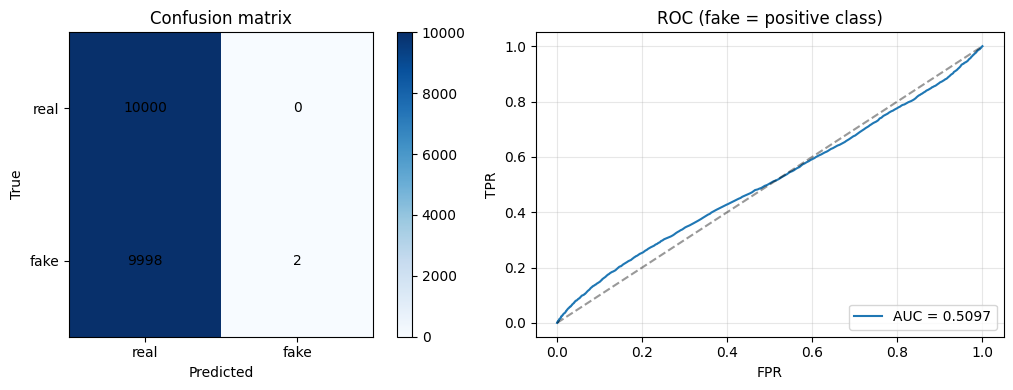

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

im = axes[0].imshow(cm, cmap="Blues")
axes[0].set_title("Confusion matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["real", "fake"])
axes[0].set_yticklabels(["real", "fake"])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i, j]), ha="center", va="center", color="black")
fig.colorbar(im, ax=axes[0], fraction=0.046)

fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[1].plot(fpr, tpr, label=f"AUC = {metrics['auc']:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
axes[1].set_title("ROC (fake = positive class)")
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_name = f"{EVAL_CONFIG['model']}_{EVAL_CONFIG['dataset']}_{EVAL_CONFIG['split']}_{stamp}"
report = {
    "run_name": run_name,
    "eval_config": EVAL_CONFIG,
    "checkpoint": str(ckpt_path.resolve()),
    "data_root": str(DATA_ROOT.resolve()),
    "metrics": metrics,
    "confusion_matrix": cm.tolist(),
    "checkpoint_val_metrics": ckpt.get("val_metrics"),
}

out_json = OUT_DIR / f"{run_name}.json"
out_json.write_text(json.dumps(report, indent=2), encoding="utf-8")
print("Saved report ->", out_json.resolve())

Saved report -> /content/eval_outputs/dual_maxvit_cifake_test_20260516_194144.json
